In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from Greedy_SOSP import Greedy_SOSP

DATA_PATH = Path("data") / "kolkata_road_drive.txt"
RESULTS_GSOSP_CSV = Path("kolkata_road_drive_results_GSOSP.csv")

In [2]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 91,886 edges from data\kolkata_road_drive.txt


In [3]:
EDGE_COUNTS = [10_000, 20_000, 30_000, 40_000, 50_000, 60_000, 70_000, 80_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Greedy_SOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 45/45 [00:09<00:00,  4.56it/s]


,edges,nodes,runtime,trial
0,10000,5888,0.013816,1
1,10000,5888,0.008556,2
2,10000,5888,0.008280,3
3,10000,5888,0.008378,4
4,10000,5888,0.007658,5


In [4]:
results_df.to_csv(RESULTS_GSOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_GSOSP_CSV}")

Saved runtime results to kolkata_road_drive_results_GSOSP.csv


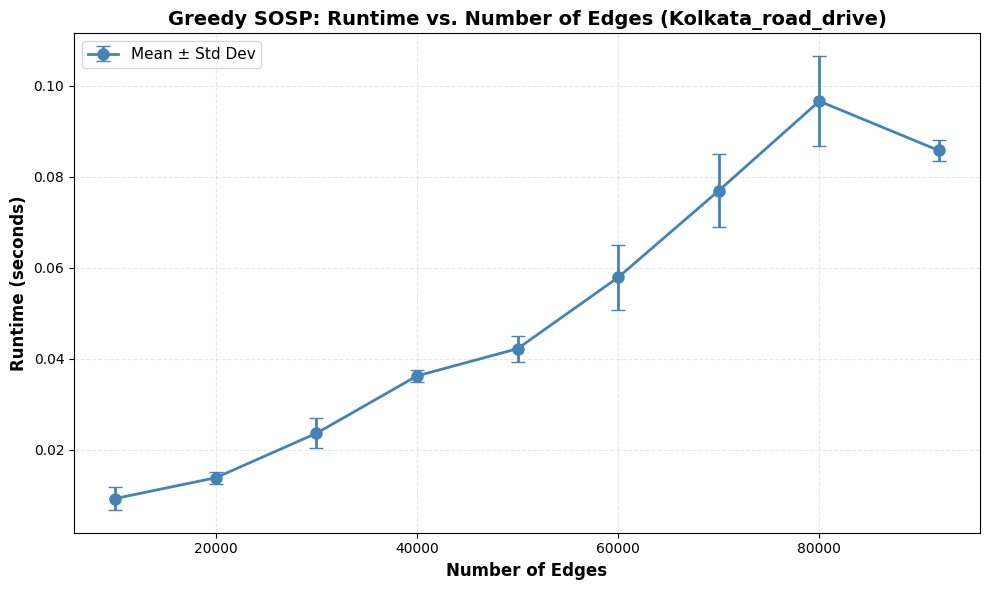


Runtime Statistics by Edges:
 edges     mean      std
 10000 0.009338 0.002526
 20000 0.013906 0.001309
 30000 0.023662 0.003263
 40000 0.036263 0.001322
 50000 0.042254 0.002860
 60000 0.057907 0.007075
 70000 0.076961 0.008052
 80000 0.096630 0.009915
 91886 0.085793 0.002268


In [5]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Greedy SOSP: Runtime vs. Number of Edges (Kolkata_road_drive)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

In [6]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from Robust_MOSP import  Robust_MOSP

DATA_PATH = Path("data") / "kolkata_road_drive.txt"
RESULTS_RMOSP_CSV = Path("kolkata_road_drive_results_RMOSP.csv")

In [7]:
def load_roadnet_edges(path):
    """Read the RoadNet-CA directed edge list from the dataset file."""
    return pd.read_csv(
        path,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["source", "target"],
        dtype={"source": int, "target": int},
    )


def build_subgraph(edge_df):
    """Build a directed graph from an edge DataFrame."""
    G = nx.DiGraph()
    G.add_edges_from(edge_df.itertuples(index=False, name=None))
    return G


edge_df = load_roadnet_edges(DATA_PATH)
print(f"Loaded {len(edge_df):,} edges from {DATA_PATH}")

Loaded 91,886 edges from data\kolkata_road_drive.txt


In [8]:
EDGE_COUNTS = [10_000, 20_000, 30_000, 40_000, 50_000, 60_000, 70_000, 80_000, len(edge_df)]
REPEAT = 5

results = []

total_runs = len(EDGE_COUNTS) * REPEAT
with tqdm(total=total_runs, desc="RoadNet-CA experiments") as pbar:
    for edges_count in EDGE_COUNTS:
        subset = edge_df.iloc[:edges_count]
        for trial in range(REPEAT):
            G = build_subgraph(subset)
            start = time.perf_counter()
            Robust_MOSP(G)
            end = time.perf_counter()

            results.append({
                "edges": edges_count,
                "nodes": G.number_of_nodes(),
                "runtime": end - start,
                "trial": trial + 1,
            })
            pbar.update(1)


results_df = pd.DataFrame(results)
results_df.head()

RoadNet-CA experiments: 100%|██████████| 45/45 [03:30<00:00,  4.68s/it]


,edges,nodes,runtime,trial
0,10000,5888,1.314200,1
1,10000,5888,1.091547,2
2,10000,5888,0.868849,3
3,10000,5888,0.893317,4
4,10000,5888,0.958844,5


In [9]:
results_df.to_csv(RESULTS_RMOSP_CSV, index=False)
print(f"Saved runtime results to {RESULTS_RMOSP_CSV}")

Saved runtime results to kolkata_road_drive_results_RMOSP.csv


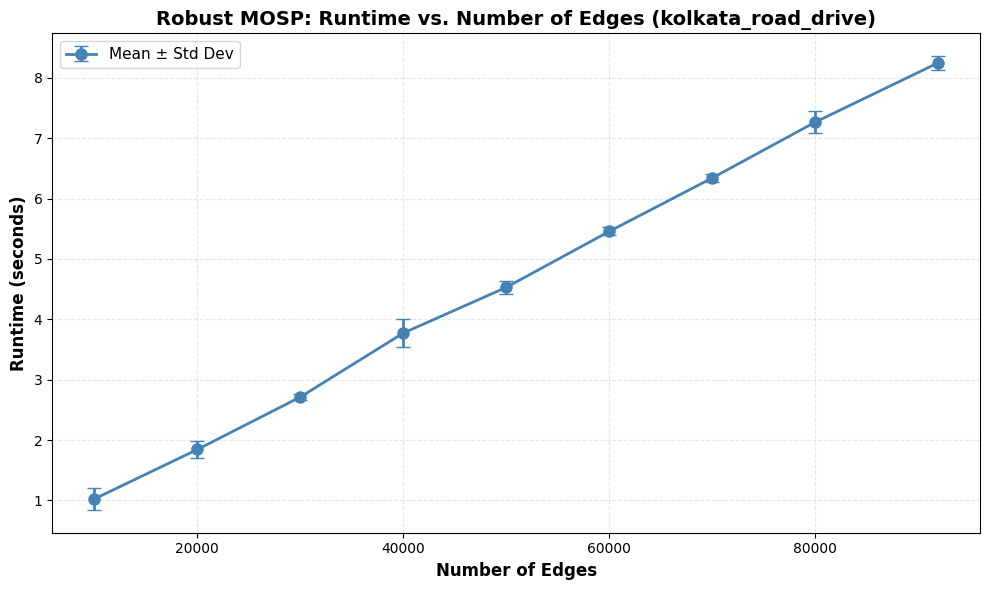


Runtime Statistics by Edges:
 edges     mean      std
 10000 1.025351 0.183142
 20000 1.844333 0.142923
 30000 2.713484 0.041524
 40000 3.772564 0.224795
 50000 4.529919 0.111763
 60000 5.456604 0.065896
 70000 6.341218 0.061150
 80000 7.265951 0.183151
 91886 8.244419 0.114606


In [10]:
# Load and plot runtime results for Greedy_SOSP
gsosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
runtime_by_edges = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot mean runtime with error bars
ax.errorbar(runtime_by_edges['edges'], runtime_by_edges['mean'], 
            yerr=runtime_by_edges['std'], marker='o', linewidth=2, 
            markersize=8, capsize=5, label='Mean ± Std Dev', color='steelblue')

# Formatting
ax.set_xlabel('Number of Edges', fontsize=12, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=12, fontweight='bold')
ax.set_title('Robust MOSP: Runtime vs. Number of Edges (kolkata_road_drive)', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(fontsize=11)

# Use log scale for x-axis if there's a large range
if runtime_by_edges['edges'].max() / runtime_by_edges['edges'].min() > 50:
    ax.set_xscale('log')
    ax.set_xlabel('Number of Edges (log scale)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\nRuntime Statistics by Edges:")
print(runtime_by_edges.to_string(index=False))

**combined greedy sosp and robust mosp**

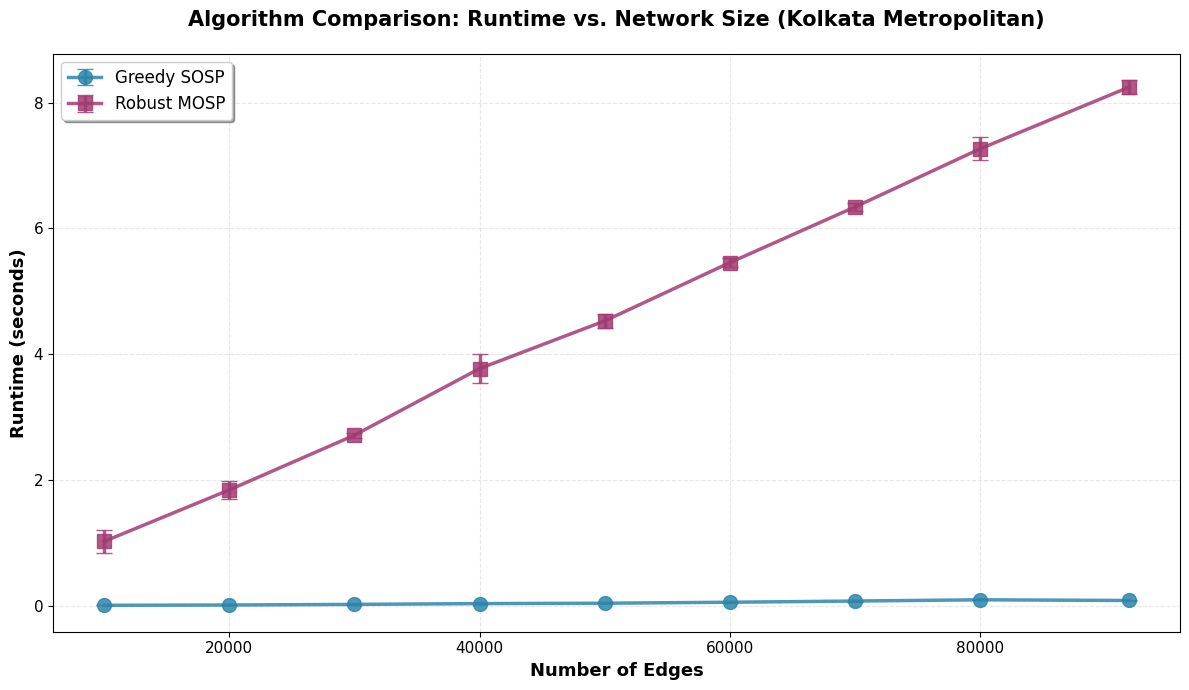

COMBINED ALGORITHM COMPARISON - Kolkata Metropolitan

Greedy SOSP Runtime Statistics:
 edges     mean      std
 10000 0.009338 0.002526
 20000 0.013906 0.001309
 30000 0.023662 0.003263
 40000 0.036263 0.001322
 50000 0.042254 0.002860
 60000 0.057907 0.007075
 70000 0.076961 0.008052
 80000 0.096630 0.009915
 91886 0.085793 0.002268

Robust MOSP Runtime Statistics:
 edges     mean      std
 10000 1.025351 0.183142
 20000 1.844333 0.142923
 30000 2.713484 0.041524
 40000 3.772564 0.224795
 50000 4.529919 0.111763
 60000 5.456604 0.065896
 70000 6.341218 0.061150
 80000 7.265951 0.183151
 91886 8.244419 0.114606

SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):
Edges:  10000 | Speedup:   109.81x
Edges:  20000 | Speedup:   132.62x
Edges:  30000 | Speedup:   114.68x
Edges:  40000 | Speedup:   104.03x
Edges:  50000 | Speedup:   107.21x
Edges:  60000 | Speedup:    94.23x
Edges:  70000 | Speedup:    82.39x
Edges:  80000 | Speedup:    75.19x
Edges:  91886 | Speedup:    96.10x


In [3]:
# Combined plot: Greedy SOSP vs Robust MOSP on RoadNet-CA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
RESULTS_GSOSP_CSV = Path("kolkata_road_drive_results_GSOSP.csv")
RESULTS_RMOSP_CSV = Path("kolkata_road_drive_results_RMOSP.csv")

# Load results from both algorithms
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)
rmosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
gsosp_runtime = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
gsosp_runtime['algorithm'] = 'Greedy SOSP'

rmosp_runtime = rmosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
rmosp_runtime['algorithm'] = 'Robust MOSP'

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Greedy SOSP
ax.errorbar(gsosp_runtime['edges'], gsosp_runtime['mean'], 
            yerr=gsosp_runtime['std'], marker='o', linewidth=2.5, 
            markersize=10, capsize=6, label='Greedy SOSP', 
            color='#2E86AB', alpha=0.85)

# Plot Robust MOSP
ax.errorbar(rmosp_runtime['edges'], rmosp_runtime['mean'], 
            yerr=rmosp_runtime['std'], marker='s', linewidth=2.5, 
            markersize=10, capsize=6, label='Robust MOSP', 
            color='#A23B72', alpha=0.85)

# Formatting for research paper
ax.set_xlabel('Number of Edges', fontsize=13, fontweight='bold')
ax.set_ylabel('Runtime (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Algorithm Comparison: Runtime vs. Network Size (Kolkata Metropolitan)', 
             fontsize=15, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=12, loc='upper left', frameon=True, shadow=True)

# Add tick formatting
ax.tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout()
# plt.savefig('roadNet-CA_combined_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print comparison statistics
print("=" * 70)
print("COMBINED ALGORITHM COMPARISON - Kolkata Metropolitan")
print("=" * 70)
print("\nGreedy SOSP Runtime Statistics:")
print(gsosp_runtime[['edges', 'mean', 'std']].to_string(index=False))
print("\nRobust MOSP Runtime Statistics:")
print(rmosp_runtime[['edges', 'mean', 'std']].to_string(index=False))

# Calculate speedup
print("\n" + "=" * 70)
print("SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):")
print("=" * 70)
for edges in gsosp_runtime['edges']:
    gsosp_mean = gsosp_runtime[gsosp_runtime['edges'] == edges]['mean'].values[0]
    rmosp_mean = rmosp_runtime[rmosp_runtime['edges'] == edges]['mean'].values[0]
    speedup = rmosp_mean / gsosp_mean
    print(f"Edges: {edges:>6} | Speedup: {speedup:>8.2f}x")

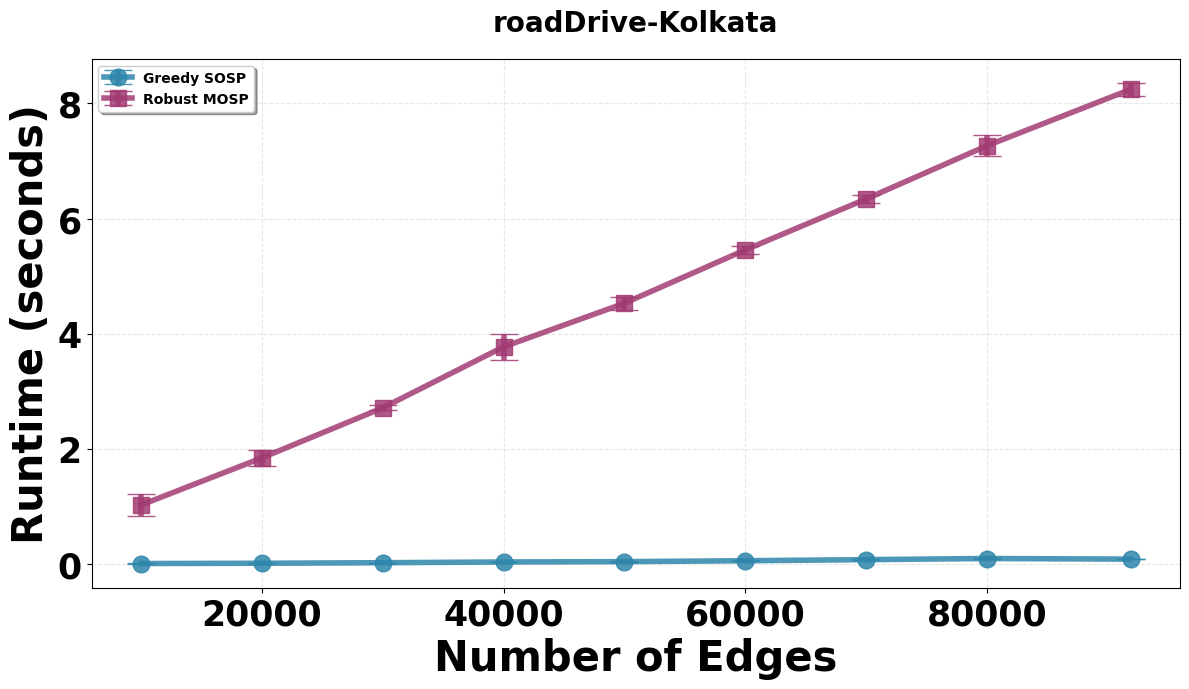

COMBINED ALGORITHM COMPARISON - roadDrive-Kolkata

Greedy SOSP Runtime Statistics:
 edges     mean      std
 10000 0.009338 0.002526
 20000 0.013906 0.001309
 30000 0.023662 0.003263
 40000 0.036263 0.001322
 50000 0.042254 0.002860
 60000 0.057907 0.007075
 70000 0.076961 0.008052
 80000 0.096630 0.009915
 91886 0.085793 0.002268

Robust MOSP Runtime Statistics:
 edges     mean      std
 10000 1.025351 0.183142
 20000 1.844333 0.142923
 30000 2.713484 0.041524
 40000 3.772564 0.224795
 50000 4.529919 0.111763
 60000 5.456604 0.065896
 70000 6.341218 0.061150
 80000 7.265951 0.183151
 91886 8.244419 0.114606

SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):
Edges:  10000 | Speedup:   109.81x
Edges:  20000 | Speedup:   132.62x
Edges:  30000 | Speedup:   114.68x
Edges:  40000 | Speedup:   104.03x
Edges:  50000 | Speedup:   107.21x
Edges:  60000 | Speedup:    94.23x
Edges:  70000 | Speedup:    82.39x
Edges:  80000 | Speedup:    75.19x
Edges:  91886 | Speedup:    96.10x


In [1]:
# Combined plot: Greedy SOSP vs Robust MOSP on RoadNet-CA
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Define paths
RESULTS_GSOSP_CSV = Path("kolkata_road_drive_results_GSOSP.csv")
RESULTS_RMOSP_CSV = Path("kolkata_road_drive_results_RMOSP.csv")

# Load results from both algorithms
gsosp_results = pd.read_csv(RESULTS_GSOSP_CSV)
rmosp_results = pd.read_csv(RESULTS_RMOSP_CSV)

# Aggregate runtimes by edges (mean and std)
gsosp_runtime = gsosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
gsosp_runtime['algorithm'] = 'Greedy SOSP'

rmosp_runtime = rmosp_results.groupby('edges')['runtime'].agg(['mean', 'std']).reset_index()
rmosp_runtime['algorithm'] = 'Robust MOSP'

# Create the combined plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot Greedy SOSP
ax.errorbar(gsosp_runtime['edges'], gsosp_runtime['mean'], 
            yerr=gsosp_runtime['std'], marker='o', linewidth=4, 
            markersize=12, capsize=10, label='Greedy SOSP', 
            color='#2E86AB', alpha=0.85)

# Plot Robust MOSP
ax.errorbar(rmosp_runtime['edges'], rmosp_runtime['mean'], 
            yerr=rmosp_runtime['std'], marker='s', linewidth=4, 
            markersize=12, capsize=10, label='Robust MOSP', 
            color='#A23B72', alpha=0.85)

# Formatting for research paper
ax.set_xlabel('Number of Edges', fontsize=30, fontweight='heavy')
ax.set_ylabel('Runtime (seconds)', fontsize=30, fontweight='heavy')

ax.set_title('roadDrive-Kolkata', 
             fontsize=20, fontweight='bold', pad=20)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=20, loc='upper left', frameon=True, shadow=True, prop={'weight': 'bold'})

# Add tick formatting
ax.tick_params(axis='both', which='major', labelsize=25)

# Set fontweight for tick labels
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.savefig('roadDrive-Kolkata_performance_comparison.pdf', dpi=600, bbox_inches='tight')
plt.show()










# Print comparison statistics
print("=" * 70)
print("COMBINED ALGORITHM COMPARISON - roadDrive-Kolkata")
print("=" * 70)
print("\nGreedy SOSP Runtime Statistics:")
print(gsosp_runtime[['edges', 'mean', 'std']].to_string(index=False))
print("\nRobust MOSP Runtime Statistics:")
print(rmosp_runtime[['edges', 'mean', 'std']].to_string(index=False))

# Calculate speedup
print("\n" + "=" * 70)
print("SPEEDUP ANALYSIS (Robust MOSP / Greedy SOSP):")
print("=" * 70)
for edges in gsosp_runtime['edges']:
    gsosp_mean = gsosp_runtime[gsosp_runtime['edges'] == edges]['mean'].values[0]
    rmosp_mean = rmosp_runtime[rmosp_runtime['edges'] == edges]['mean'].values[0]
    speedup = rmosp_mean / gsosp_mean
    print(f"Edges: {edges:>6} | Speedup: {speedup:>8.2f}x")